In [12]:
import pandas as pd

In [13]:
df = pd.read_csv(r"C:\Users\sumit\DATA_SCIENCE\CodeAlpha INTERNSHIP\Task1\Iris.csv")
display(df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [15]:
print('\nDescriptive Statistics:')
display(df.describe())


Descriptive Statistics:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [16]:
print('\nMissing Values:')
display(df.isnull().sum())


Missing Values:


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Separate features (X) and target (y)
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (105, 4)
Testing set shape: (45, 4)


In [18]:
# Initialize and train a Logistic Regression model
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [19]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00


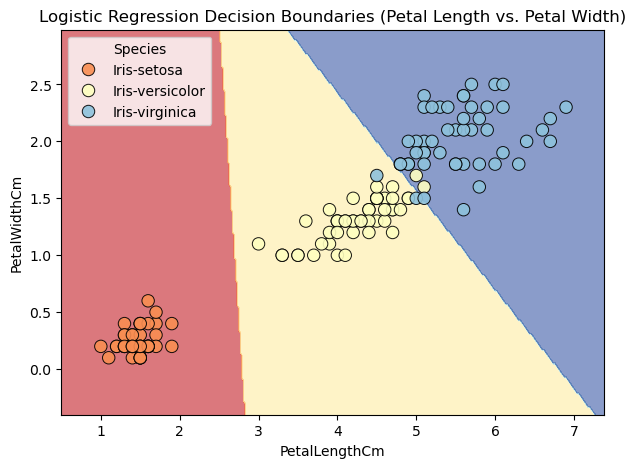

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# 1. Select the features
X_vis = X[["PetalLengthCm", "PetalWidthCm"]]

# 2. Retrain the model
model_vis = LogisticRegression(max_iter=200, random_state=42)
model_vis.fit(X_vis, y)

# 3. Create a meshgrid for decision boundaries
x_min, x_max = X_vis["PetalLengthCm"].min() - 0.5, X_vis["PetalLengthCm"].max() + 0.5
y_min, y_max = X_vis["PetalWidthCm"].min() - 0.5, X_vis["PetalWidthCm"].max() + 0.5
h = 0.02  # step size

x_mesh, y_mesh = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 4. FIX: Convert the meshgrid array into a DataFrame with matching feature names
mesh_points = np.c_[x_mesh.ravel(), y_mesh.ravel()]
X_mesh_df = pd.DataFrame(mesh_points, columns=["PetalLengthCm", "PetalWidthCm"])

# 5. Predict classifications using the DataFrame
Z = model_vis.predict(X_mesh_df)
Z = Z.reshape(x_mesh.shape)

# 6. Map species names to numerical values for plotting colors
species_map = {"Iris-setosa": 0, "Iris-versicolor": 1, "Iris-virginica": 2}
Z_numeric = np.vectorize(species_map.get)(Z)

# 7. Plotting
plt.figure(figsize=(8, 6))

# Plot decision boundaries
plt.contourf(x_mesh, y_mesh, Z_numeric, cmap=plt.cm.RdYlBu, alpha=0.6)

# Plot training points
sns.scatterplot(
    x=X_vis["PetalLengthCm"],
    y=X_vis["PetalWidthCm"],
    hue=y,
    palette=sns.color_palette("RdYlBu", n_colors=3),
    edgecolor="k",
    s=80,
    alpha=0.9,
)

plt.xlabel("PetalLengthCm")
plt.ylabel("PetalWidthCm")
plt.title(
    "Logistic Regression Decision Boundaries (Petal Length vs. Petal Width)"
)
plt.show()
